### ASSIGNMENT NO.: 03
#### Title:  A Sentiment Analysis Model for Evaluating Customer Feedback on Products and Services  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/AIPD/Indian_Domestic_Airline.csv")
df

,AirLine_Name,Rating - 10,Title,Name,Date,Review,Recommond
0,AirAsia India,6.0,"""crew were welcoming""",V Bakshi,14th October 2023,✅ Trip Verified | I had booked this fare at a ...,yes
1,AirAsia India,1.0,"""furious and disappointed""",G Oscar,14th October 2023,✅ Trip Verified | I travel at least four times...,no
2,AirAsia India,10.0,"""amazing service and support""",Rahul Verma,14th October 2023,✅ Trip Verified | Taking this opportunity to a...,yes
3,AirAsia India,1.0,"""Waste of time and money""",G Akron,14th October 2023,✅ Trip Verified | The worst airlines in the hi...,no
4,AirAsia India,8.0,"""thumbs up to boarding crew""",Sirajudeen Jawahar ali,14th October 2023,✅ Trip Verified | Would like to give big thum...,yes
...,...,...,...,...,...,...,...
2205,Vistara,8.0,"""Vistara was a good experience""",Rudra Bhattacharya,15th June 2016,"Goa to Mumbai, and Vistara was a good experien...",yes
2206,Vistara,6.0,"""the journey was satisfactory""",Atharva Agashe,15th June 2016,Mumbai to Bengaluru. This was my third time fl...,yes
2207,Vistara,10.0,"""value for money""",Abhishek Ghamande,15th June 2016,Flew Vistara for the first time in February fr...,yes
2208,Vistara,8.0,"""aircraft was new and fresh""",Samarendra Patra,15th June 2016,Bhubaneswar to Delhi with Vistara. I had booke...,yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2210 entries, 0 to 2209
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AirLine_Name  2210 non-null   object 
 1   Rating - 10   2206 non-null   float64
 2   Title         2210 non-null   object 
 3   Name          2210 non-null   object 
 4   Date          2210 non-null   object 
 5   Review        2210 non-null   object 
 6   Recommond     2210 non-null   object 
dtypes: float64(1), object(6)
memory usage: 121.0+ KB


In [ ]:
df["Recommond"].value_counts()

,count
Recommond,
no,1448
yes,762


In [ ]:
df.isnull().sum()

,0
AirLine_Name,0
Rating - 10,4
Title,0
Name,0
Date,0
Review,0
Recommond,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
AirLine_Name,0
Rating - 10,0
Title,0
Name,0
Date,0
Review,0
Recommond,0


**Text Preprocessing**

In [ ]:
df['Review'] = df['Review'].str.lower()

In [ ]:
import re

def clean_text(text):
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_review'] = df['Review'].apply(clean_text)

**Tokenization**

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

df['tokens'] = df['clean_review'].apply(word_tokenize)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


**Stopword Removal**

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['tokens'] = df['tokens'].apply(
    lambda x: [word for word in x if word not in stop_words]
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


**Lemmatization**

In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

[nltk_data] Downloading package wordnet to /root/nltk_data...


**Rejoin Tokens**

In [ ]:
df['final_review'] = df['tokens'].apply(lambda x: " ".join(x))

**Feature Extraction: TF-IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['final_review'])

**Label Encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['Recommond'])

**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

**Logistic Regression Model**

In [ ]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression()
model1.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model1.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9154078549848943


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

          no       0.90      0.98      0.94       438
         yes       0.96      0.78      0.86       224

    accuracy                           0.92       662
   macro avg       0.93      0.88      0.90       662
weighted avg       0.92      0.92      0.91       662



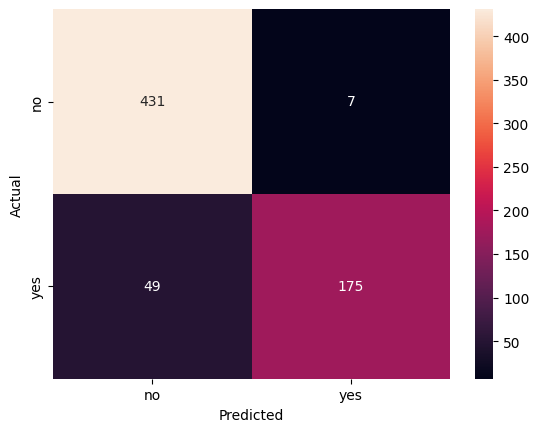

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Model Testing with New Reviews**

In [ ]:
new_review = ["The flight was delayed and staff was unhelpful"]
new_review_clean = clean_text(new_review[0])
new_review_tfidf = tfidf.transform([new_review_clean])

prediction = model1.predict(new_review_tfidf)
le.inverse_transform(prediction)


array(['no'], dtype=object)

**Multinomial Naive Bayes Model**

In [ ]:
from sklearn.naive_bayes import MultinomialNB

model2 = MultinomialNB()
model2.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred = model2.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8685800604229608


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

          no       0.84      0.99      0.91       438
         yes       0.97      0.63      0.77       224

    accuracy                           0.87       662
   macro avg       0.90      0.81      0.84       662
weighted avg       0.88      0.87      0.86       662



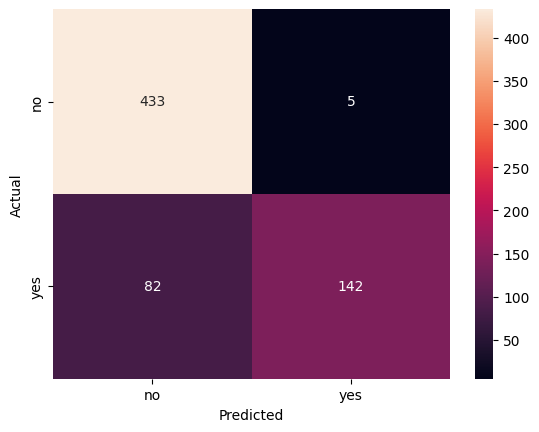

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
new_review = ["The flight was delayed and staff was unhelpful"]
new_review_clean = clean_text(new_review[0])
new_review_tfidf = tfidf.transform([new_review_clean])

prediction = model2.predict(new_review_tfidf)
le.inverse_transform(prediction)


array(['no'], dtype=object)

**Support Vector Machine Model**

In [ ]:
from sklearn.svm import SVC

model3 = SVC()
model3.fit(X_train, y_train)

SVC()

In [ ]:
y_pred = model3.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9259818731117825


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

          no       0.91      0.98      0.95       438
         yes       0.96      0.82      0.88       224

    accuracy                           0.93       662
   macro avg       0.94      0.90      0.91       662
weighted avg       0.93      0.93      0.92       662



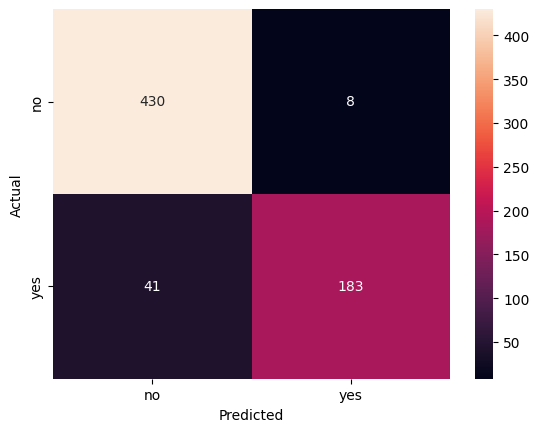

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
new_review = ["The flight was delayed and staff was unhelpful"]
new_review_clean = clean_text(new_review[0])
new_review_tfidf = tfidf.transform([new_review_clean])

prediction = model3.predict(new_review_tfidf)
le.inverse_transform(prediction)


array(['no'], dtype=object)